In [1]:
import pandas as pd
import glob
import string
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from nltk.corpus import wordnet
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, pipeline
from datasets import Dataset
from sklearn.preprocessing import LabelEncoder
import torch
import matplotlib.pyplot as plt
import nlpaug.augmenter.word as naw
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from torch import nn

c:\Users\victo\OneDrive\Documents\Data science course\Final-Capstone-Project\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


Combining separte files into one

In [26]:
folder_path = "CSV files/*.csv"
all_files = glob.glob(folder_path)
df_list = [pd.read_csv(filename) for filename in all_files]
df = pd.concat(df_list, ignore_index=True)

In [27]:
df.head()

,,Time,Time.1,Place,Place.1,Place.2,Place.3,Place.4,Place.5,Place.6,...,Events.4,Events.5,Assessments,Assessments.1,Report 1,Report 1.1,Report 2,Report 2.1,Report 1.2,Unnamed: 125
0,ACN,Date,Local Time Of Day,Locale Reference,State Reference,Relative Position.Angle.Radial,Relative Position.Distance.Nautical Miles,Altitude.AGL.Single Value,Altitude.MSL.Single Value,Latitude / Longitude (UAS),...,When Detected,Result,Contributing Factors / Situations,Primary Problem,Narrative,Callback,Narrative,Callback,Synopsis,NaN
1,1714400,202001,0001-0600,ORD.Airport,IL,NaN,NaN,NaN,15000,NaN,...,In-flight,Air Traffic Control Issued New Clearance; Air ...,Aircraft; Company Policy,Company Policy,To be clear I did not have a lot going on and ...,NaN,NaN,NaN,A TRACON Departure Controller reported two air...,NaN
2,1714553,202001,1801-2400,ZHU.ARTCC,TX,NaN,NaN,NaN,14000,NaN,...,In-flight,Flight Crew Became Reoriented; General Physica...,Human Factors; Environment - Non Weather Related,Environment - Non Weather Related,While descending into PIB out of 14;000 ft. MS...,NaN,NaN,NaN,CRJ Captain reported that a laser shone repeat...,NaN
3,1714675,202001,1801-2400,ZZZ.ARTCC,US,NaN,NaN,NaN,9000,NaN,...,In-flight,Flight Crew Returned To Departure Airport; Fli...,Aircraft; Weather; Procedure,Weather,I was boarding the aircraft when a my destinat...,NaN,NaN,NaN,Pilot reported weather and a closed destinatio...,NaN
4,1714708,202001,0601-1200,ZZZ.Airport,US,NaN,NaN,0,NaN,NaN,...,In-flight,General None Reported / Taken,Procedure; Logbook Entry; Human Factors,Ambiguous,I had a ferry flight that went out of service ...,NaN,We departed ZZZ ferrying an un-airworthy aircr...,NaN,Air carrier Dispatcher and flight crew reporte...,NaN


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31141 entries, 0 to 31140
Columns: 126 entries,   to Unnamed: 125
dtypes: float64(1), str(125)
memory usage: 104.8 MB


In [29]:
df_1 = df.copy()

In [30]:
df_1 = df_1[['Assessments.1','Report 1']]

In [31]:
df_1.head()

,Assessments.1,Report 1
0,Primary Problem,Narrative
1,Company Policy,To be clear I did not have a lot going on and ...
2,Environment - Non Weather Related,While descending into PIB out of 14;000 ft. MS...
3,Weather,I was boarding the aircraft when a my destinat...
4,Ambiguous,I had a ferry flight that went out of service ...


In [32]:
df_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 31141 entries, 0 to 31140
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Assessments.1  31064 non-null  str  
 1   Report 1       31138 non-null  str  
dtypes: str(2)
memory usage: 42.1 MB


Checking for missing values

In [33]:
df_1.isnull().sum()/len(df_1) * 100

Assessments.1    0.247262
Report 1         0.009634
dtype: float64

Dropping Missing Values

In [34]:
df_1.dropna(inplace = True)

In [35]:
df_1.info()

<class 'pandas.DataFrame'>
Index: 31064 entries, 0 to 31140
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Assessments.1  31064 non-null  str  
 1   Report 1       31064 non-null  str  
dtypes: str(2)
memory usage: 42.3 MB


In [36]:
df_1.isnull().sum()/len(df_1) * 100

Assessments.1    0.0
Report 1         0.0
dtype: float64

Changing column name to first row

In [37]:
df_1.columns = df_1.iloc[0]
df_1 = df_1.drop(df.index[0])
df_1 = df_1.reset_index(drop=True)

In [38]:
df_1.head()

,Primary Problem,Narrative
0,Company Policy,To be clear I did not have a lot going on and ...
1,Environment - Non Weather Related,While descending into PIB out of 14;000 ft. MS...
2,Weather,I was boarding the aircraft when a my destinat...
3,Ambiguous,I had a ferry flight that went out of service ...
4,Aircraft,We were flying at 2500 ft. I started losing el...


In [39]:
df_1['Primary Problem'].value_counts()

Primary Problem
Human Factors                                         10823
Aircraft                                               9802
Procedure                                              2913
Ambiguous                                              2490
Weather                                                1059
Environment - Non Weather Related                       930
Airport                                                 786
Chart Or Publication                                    447
Airspace Structure                                      411
ATC Equipment / Nav Facility / Buildings                410
Company Policy                                          408
Software and Automation                                 177
Equipment / Tooling                                     103
Staffing                                                 96
MEL                                                      69
Incorrect / Not Installed / Unavailable Part             55
Manuals                 

In [40]:
df_2 = df_1.copy()

[]

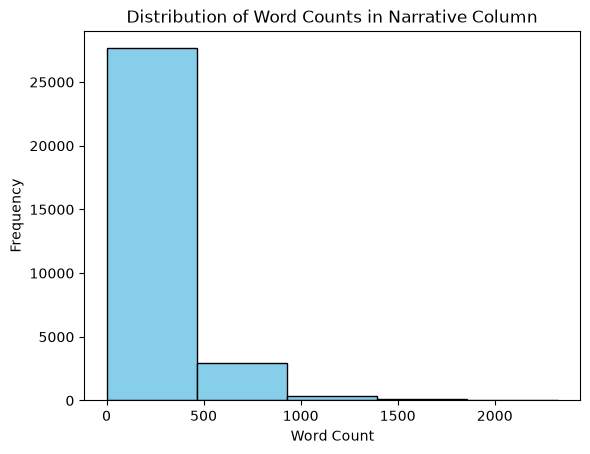

In [41]:
df_2['word_count'] = df_2['Narrative'].str.split().str.len()

fig, ax = plt.subplots()
ax.hist(df_2['word_count'], bins=5, edgecolor='black', color='skyblue')
ax.set_title('Distribution of Word Counts in Narrative Column')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')

plt.plot()

Making narrative lowercase

In [42]:
df_1['Narrative'] = df_1['Narrative'].str.lower()
df_1['Narrative'][0]

"to be clear i did not have a lot going on and my complexity was not high. that is why this was a non-event. however; ord was super busy on two runways for a little bit and i am sure the tower was very busy landing 28c departing 28r and 22l. ground could have also been busy so that is why i put the information in there on complexity and amount of volume. here is what happened; we were on outboards at ord. there were a lot of aircraft going over the airport to balance the runways. i had a strip print and an aircraft depart and tag up. it was aircraft z. i was waiting for this aircraft to call on. i was waiting and waiting and making a plan. then the aircraft started climbing out of 5;000 feet; so i reached out and tried to turn the aircraft. he didn't turn or answer. i didn't know what happened or was happening. then i did it again. i was just about to call back to the tower and the position next to me was giving a briefing and they turned their aircraft to earnd.aircraft x. now they de

In [43]:
punc = string.punctuation

Removing punctuation

In [44]:
def remove_punc(text):
    return text.translate(str.maketrans('', '', punc))

In [45]:
df_1['Narrative'] = df_1['Narrative'].apply(remove_punc)

In [46]:
df_1['Narrative'][0]

'to be clear i did not have a lot going on and my complexity was not high that is why this was a nonevent however ord was super busy on two runways for a little bit and i am sure the tower was very busy landing 28c departing 28r and 22l ground could have also been busy so that is why i put the information in there on complexity and amount of volume here is what happened we were on outboards at ord there were a lot of aircraft going over the airport to balance the runways i had a strip print and an aircraft depart and tag up it was aircraft z i was waiting for this aircraft to call on i was waiting and waiting and making a plan then the aircraft started climbing out of 5000 feet so i reached out and tried to turn the aircraft he didnt turn or answer i didnt know what happened or was happening then i did it again i was just about to call back to the tower and the position next to me was giving a briefing and they turned their aircraft to earndaircraft x now they departed off of two diffe

Removing Stopwords

In [47]:
#nltk.download('stopwords')

In [48]:
stopword = stopwords.words('english')
def remove_stopwords(text):
    new_text = []
    
    for word in text.split():
        if word in stopword:
            new_text.append('')
        else:
            new_text.append(word)
    x = new_text[:]
    new_text.clear()
    return " ".join(x)

In [49]:
df_1['Narrative'] = df_1['Narrative'].apply(remove_stopwords)

In [50]:
df_1['Narrative'][0]

'  clear      lot going    complexity   high       nonevent however ord  super busy  two runways   little bit    sure  tower   busy landing 28c departing 28r  22l ground could  also  busy      put  information    complexity  amount  volume    happened    outboards  ord    lot  aircraft going   airport  balance  runways    strip print   aircraft depart  tag    aircraft z   waiting   aircraft  call    waiting  waiting  making  plan   aircraft started climbing   5000 feet   reached   tried  turn  aircraft  didnt turn  answer  didnt know  happened   happening           call back   tower   position next    giving  briefing   turned  aircraft  earndaircraft x   departed   two different runways   said   guy next   hey see    aircraft z  chance    somehow aircraft z going westbound departing   runway 28r     frequency  aircraft x departing   runway 22l   instruction  aircraft x  given aircraft z  aircraft x took   controller said  didnt hear  indication     step     anything   time aircraft  a

Dealing with excessive whitespaces

In [51]:
df_1['Narrative'] = df_1['Narrative'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [52]:
df_1['Narrative'][0]

'clear lot going complexity high nonevent however ord super busy two runways little bit sure tower busy landing 28c departing 28r 22l ground could also busy put information complexity amount volume happened outboards ord lot aircraft going airport balance runways strip print aircraft depart tag aircraft z waiting aircraft call waiting waiting making plan aircraft started climbing 5000 feet reached tried turn aircraft didnt turn answer didnt know happened happening call back tower position next giving briefing turned aircraft earndaircraft x departed two different runways said guy next hey see aircraft z chance somehow aircraft z going westbound departing runway 28r frequency aircraft x departing runway 22l instruction aircraft x given aircraft z aircraft x took controller said didnt hear indication step anything time aircraft also departed went incorrect frequency controller send correct frequency 3 similar sounding aircraft 1 frequency two supposed climbing two supposed tried explain 

In [53]:
#nltk.download('punkt')
#nltk.download('punkt_tab')

Tokenization

In [54]:
df_1['Narrative'] = df_1['Narrative'].apply(word_tokenize)

In [55]:
df_1['Narrative'][0]

['clear',
 'lot',
 'going',
 'complexity',
 'high',
 'nonevent',
 'however',
 'ord',
 'super',
 'busy',
 'two',
 'runways',
 'little',
 'bit',
 'sure',
 'tower',
 'busy',
 'landing',
 '28c',
 'departing',
 '28r',
 '22l',
 'ground',
 'could',
 'also',
 'busy',
 'put',
 'information',
 'complexity',
 'amount',
 'volume',
 'happened',
 'outboards',
 'ord',
 'lot',
 'aircraft',
 'going',
 'airport',
 'balance',
 'runways',
 'strip',
 'print',
 'aircraft',
 'depart',
 'tag',
 'aircraft',
 'z',
 'waiting',
 'aircraft',
 'call',
 'waiting',
 'waiting',
 'making',
 'plan',
 'aircraft',
 'started',
 'climbing',
 '5000',
 'feet',
 'reached',
 'tried',
 'turn',
 'aircraft',
 'didnt',
 'turn',
 'answer',
 'didnt',
 'know',
 'happened',
 'happening',
 'call',
 'back',
 'tower',
 'position',
 'next',
 'giving',
 'briefing',
 'turned',
 'aircraft',
 'earndaircraft',
 'x',
 'departed',
 'two',
 'different',
 'runways',
 'said',
 'guy',
 'next',
 'hey',
 'see',
 'aircraft',
 'z',
 'chance',
 'somehow',

Lemmitization

In [56]:
#nltk.download('wordnet')
#nltk.download('omw-1.4')

In [57]:
#nltk.download('averaged_perceptron_tagger_eng')

In [58]:
lemmatizer = WordNetLemmatizer()

In [59]:
def lemmatize_sentence(sentence_list):
    tagged = nltk.pos_tag(sentence_list)
    
    lemmatized_output = []
    for word, tag in tagged:
        wn_tag = tag[0].upper()
        tag_dict = {"J": wordnet.ADJ,
                    "N": wordnet.NOUN,
                    "V": wordnet.VERB,
                    "R": wordnet.ADV}
        pos = tag_dict.get(wn_tag, wordnet.NOUN)
        
        lemmatized_output.append(lemmatizer.lemmatize(word, pos))
    
    return lemmatized_output

In [60]:
df_1['Narrative'] = df_1['Narrative'].apply(lemmatize_sentence)

In [61]:
df_1['Narrative'][0]

['clear',
 'lot',
 'go',
 'complexity',
 'high',
 'nonevent',
 'however',
 'ord',
 'super',
 'busy',
 'two',
 'runway',
 'little',
 'bit',
 'sure',
 'tower',
 'busy',
 'land',
 '28c',
 'depart',
 '28r',
 '22l',
 'ground',
 'could',
 'also',
 'busy',
 'put',
 'information',
 'complexity',
 'amount',
 'volume',
 'happen',
 'outboard',
 'ord',
 'lot',
 'aircraft',
 'go',
 'airport',
 'balance',
 'runway',
 'strip',
 'print',
 'aircraft',
 'depart',
 'tag',
 'aircraft',
 'z',
 'wait',
 'aircraft',
 'call',
 'wait',
 'wait',
 'make',
 'plan',
 'aircraft',
 'start',
 'climb',
 '5000',
 'foot',
 'reach',
 'tried',
 'turn',
 'aircraft',
 'didnt',
 'turn',
 'answer',
 'didnt',
 'know',
 'happen',
 'happen',
 'call',
 'back',
 'tower',
 'position',
 'next',
 'give',
 'briefing',
 'turn',
 'aircraft',
 'earndaircraft',
 'x',
 'depart',
 'two',
 'different',
 'runway',
 'say',
 'guy',
 'next',
 'hey',
 'see',
 'aircraft',
 'z',
 'chance',
 'somehow',
 'aircraft',
 'z',
 'go',
 'westbound',
 'depar

In [62]:
df_1['Narrative'] = df_1['Narrative'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)

Train test split

In [63]:
X = df_1['Narrative'].copy()
y = df_1['Primary Problem'].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

In [64]:
#vectorizer = TfidfVectorizer()
#X_train_tfidf = vectorizer.fit_transform(X_train)

In [65]:
#X_test_tfidf = vectorizer.transform(X_test)

Random Forest Model

In [66]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', RandomForestClassifier(class_weight = 'balanced'))
])

In [67]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](27,)","['ATC Equipment / Nav Facility / Buildings', 'ATC Equipment / Nav Facility / Buildings; Aircraft','Aircraft',..., 'Staffing','Weather','Weather; Human Factors']"
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True


In [68]:
test_pred_rf = pipeline.predict(X_test)

In [69]:
train_pred_rf = pipeline.predict(X_train)

In [70]:
print(classification_report(y_test, test_pred_rf))

                                              precision    recall  f1-score   support

    ATC Equipment / Nav Facility / Buildings       0.30      0.15      0.20        82
                                    Aircraft       0.74      0.87      0.80      1950
                                     Airport       0.33      0.64      0.43       148
                          Airspace Structure       0.18      0.24      0.20        71
                                   Ambiguous       0.24      0.29      0.26       465
                        Chart Or Publication       0.57      0.50      0.53        78
                              Company Policy       0.40      0.35      0.37        69
           Environment - Non Weather Related       0.23      0.15      0.18       197
                         Equipment / Tooling       0.29      0.15      0.20        13
                               Human Factors       0.62      0.53      0.57      2225
                     Human Factors; Aircraft       0.

c:\Users\victo\OneDrive\Documents\Data science course\Final-Capstone-Project\env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\victo\OneDrive\Documents\Data science course\Final-Capstone-Project\env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\victo\OneDrive\Documents\Data science course\Final-Capstone-Project\env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sa

BERT, ROBERTA, AEROBERT

In [71]:
df_subset = df_2[['Narrative','Primary Problem']].copy()

In [72]:
df_subset['Narrative'] = df_subset['Narrative'].str.lower().str.strip()

In [73]:
label_encoder = LabelEncoder()
df_subset['labels'] = label_encoder.fit_transform(df_subset['Primary Problem'])
num_labels = len(label_encoder.classes_)

In [74]:
df_subset.head()

,Narrative,Primary Problem,labels
0,to be clear i did not have a lot going on and ...,Company Policy,11
1,while descending into pib out of 14;000 ft. ms...,Environment - Non Weather Related,13
2,i was boarding the aircraft when a my destinat...,Weather,28
3,i had a ferry flight that went out of service ...,Ambiguous,7
4,we were flying at 2500 ft. i started losing el...,Aircraft,2


In [75]:
df_subset['Primary Problem'] = df_subset['Primary Problem'].astype(str)
df_subset['Narrative'] = df_subset['Narrative'].astype(str)
train, val = train_test_split(df_subset, test_size=0.2, random_state=42)

In [76]:
model_name = "distilbert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(model_name)

In [94]:
model_name = "FacebookAI/roberta-base"
bert_tokenizer = AutoTokenizer.from_pretrained(model_name)

In [95]:
def tokenize_function(data):
    return bert_tokenizer(data['Narrative'], padding="max_length", truncation=True, max_length=512)

In [96]:
train.head()

,Narrative,Primary Problem,labels
0,first officer seated in the passenger section ...,Human Factors,15
1,zzz approach gave us a shortcut to final and l...,Human Factors,15
2,fwd r window shatteredabout 5-10 minutes after...,Aircraft,2
3,i; the pic of the airplane; no passengers on b...,Aircraft,2
4,i was the r-side controller. there were no oth...,Staffing,27


In [97]:
train = train.reset_index(drop=True)
val = val.reset_index(drop=True)

In [98]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 24850 entries, 0 to 24849
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Narrative        24850 non-null  str  
 1   Primary Problem  24850 non-null  str  
 2   labels           24850 non-null  int64
dtypes: int64(1), str(2)
memory usage: 33.8 MB


In [99]:
train_dataset = Dataset.from_dict(train.to_dict(orient='list'))
val_dataset = Dataset.from_dict(val.to_dict(orient='list'))

In [100]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

Map: 100%|██████████| 6213/6213 [00:01<00:00, 4963.85 examples/s]


In [101]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 8501.68it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [102]:
df_subset['labels'].value_counts()

labels
15    10823
2      9802
24     2913
7      2490
28     1059
13      930
5       786
9       447
6       411
0       410
11      408
26      177
14      103
27       96
21       69
19       55
22       48
20       11
23        8
16        4
25        3
29        2
12        1
3         1
8         1
18        1
17        1
10        1
1         1
4         1
Name: count, dtype: int64

In [103]:
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(df_subset['Primary Problem']), y=df_subset['Primary Problem']
)

In [104]:
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

In [105]:
class WeightedTrainer(Trainer):

    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        """Overrides the default loss computation to use weighted cross-entropy."""
        labels = inputs.get("labels")

        outputs = model(**inputs)
        logits = outputs.get("logits")


        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)

        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

In [106]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    

    fp16=torch.cuda.is_available(),      
    dataloader_num_workers=4,           
    eval_strategy="epoch",         
    save_strategy="epoch",
    logging_steps=50,
    report_to="none",                    
)

In [107]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    class_weights=class_weights_tensor,
)

In [108]:
trainer.train()

c:\Users\victo\OneDrive\Documents\Data science course\Final-Capstone-Project\env\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


: 

In [17]:
model.save_pretrained("./saved_bert_model")
bert_tokenizer.save_pretrained("./saved_bert_model")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.95it/s]


NameError: name 'bert_tokenizer' is not defined

Performance

AeroBERT model

![Screenshot 2026-06-29 133917.png](<attachment:Screenshot 2026-06-29 133917.png>)
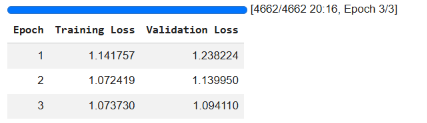

BERT Model

Roberta Model

In [91]:
model = AutoModelForSequenceClassification.from_pretrained("./saved_bert_model")
tokenizer = AutoTokenizer.from_pretrained("./saved_bert_model")

model.eval()

new_text = "During the RNAV RWY 19 approach, we encountered unforecast moderate turbulence and a shifting crosswind. While configuring the aircraft, the First Officer called 'flaps 15' out of sequence, which I selected without verifying our airspeed. This triggered an oversized pitch change. Distracted by correcting the pitch and managing the rough ride, I allowed our airspeed to decay below target, causing a high sink rate. The GPWS 'SINK RATE' alert sounded at 400 feet AGL.Recognizing we were completely unstabilized and well below the glidepath, I immediately called for a go-around, added maximum thrust, and executed the missed approach procedure."
inputs = tokenizer(new_text, return_tensors="pt", padding=True, truncation=True, max_length=512)

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
predictions = torch.softmax(logits, dim=-1)
predicted_class = torch.argmax(predictions, dim=-1)

print(f"Predicted class: {predicted_class.item()}")
print(f"Confidence scores: {predictions.detach().numpy()}")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 6901.15it/s]


Predicted class: 28
Confidence scores: [[6.9952854e-03 2.9023353e-04 1.6670560e-02 2.5449059e-04 4.0704283e-04
  8.3855651e-03 9.0869935e-03 9.1267467e-02 4.5301442e-04 4.1854298e-03
  3.1355370e-04 1.9283460e-03 2.5166507e-04 4.4410303e-02 2.6887958e-03
  5.0601650e-02 1.5244097e-03 3.9465321e-04 5.2889943e-04 9.6270244e-04
  5.8372482e-04 1.5615596e-03 2.1182757e-03 3.7666119e-04 2.1845242e-02
  6.5296446e-04 2.3481021e-02 1.2253083e-03 7.0547408e-01 1.0802037e-03]]


Testing

In [2]:
test_df = pd.read_csv('ASRS_Test_2019(Jan-Aug).csv')

In [3]:
test_df_1 = test_df.copy()

In [4]:
test_df_1 = test_df_1[['Assessments.1','Report 1']]

In [5]:
test_df_1.dropna(inplace = True)

In [7]:
test_df_1.columns = test_df_1.iloc[0]
test_df_1 = test_df_1.drop(test_df_1.index[0])
test_df_1 = test_df_1.reset_index(drop=True)

In [8]:
test_df_1.head()

,Primary Problem,Narrative
0,Weather,Aircraft X was inbound from GRACE intersection...
1,Human Factors,Aircraft X was in Canada's airspace squawking ...
2,Procedure,Aircraft X was handed off to Feeder I from ZDV...
3,Aircraft,During taxi out; ATC alerted us to a tailpipe ...
4,Weather,Approximately 70 miles south of TIJ; I turned ...


In [9]:
test_df_2 = test_df_1[['Narrative']].copy()

In [13]:
model_path = "saved_bert_model" 
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval() 

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7454.12it/s]


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(

In [16]:
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer, device=0 if torch.cuda.is_available() else -1)
predictions = classifier(test_df_2['Narrative'].tolist(), batch_size=4, truncation=True)
test_df_2['Predicted_Problem'] = [pred['label'] for pred in predictions]

KeyboardInterrupt: 